In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
from torch.distributions import Bernoulli
import xarray as xr
import xrft
import numpy as np
import matplotlib.pyplot as plt
import src.data
from scipy.stats import multivariate_normal
import pandas as pd
import functools as ft
from collections import namedtuple
from IPython.display import Markdown, display
from omegaconf import OmegaConf
import yaml
import inspect
import hydra
import os
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as colors
from matplotlib.colors import LogNorm 
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
from PIL import Image
import kornia.filters as kfilts
from torch.amp import autocast, GradScaler
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation
from skimage.morphology import disk, dilation
from sklearn.linear_model import LinearRegression

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = "cpu"

/Odyssey/private/ochapron/miniconda/miniconda3/envs/fdv/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


# Utils Functions

In [2]:
def plot_tensor(tensor, title = 'Logits Plot'):
    pos_tensor_numpy = tensor.numpy()
    plt.imshow(pos_tensor_numpy, cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.show()

def rmse_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    #mask = ~np.isnan(ds['input'])
    try:
        return rmse_based_scores(ds[ref_variable], ds[study_variable])[2:]
    except:
        return [np.nan, np.nan]

def psd_based_scores_from_ds(ds, ref_variable='tgt', study_variable='out'):
    print(ds)
    try:
        return psd_based_scores(ds[ref_variable], ds[study_variable])[1:]
    except:
        return [np.nan, np.nan]

def rmse_based_scores_lead(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def rmse_based_scores_day(da_rec, da_ref):
    # Calculate leaderboard RMSE
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return np.round(leaderboard_rmse.values, 5).item()

def rmse_based_scores(da_rec, da_ref):
    rmse_t = (
        1.0
        - (((da_rec - da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
        / (((da_ref) ** 2).mean(dim=("lon", "lat"))) ** 0.5
    )
    rmse_xy = (((da_rec - da_ref) ** 2).mean(dim=("time"))) ** 0.5
    rmse_t = rmse_t.rename("rmse_t")
    rmse_xy = rmse_xy.rename("rmse_xy")
    reconstruction_error_stability_metric = rmse_t.std().values
    leaderboard_rmse = (
        1.0 - (((da_rec - da_ref) ** 2).mean()) ** 0.5 / (((da_ref) ** 2).mean()) ** 0.5
    )
    return (
        rmse_t,
        rmse_xy,
        np.round(leaderboard_rmse.values, 5).item(),
        np.round(reconstruction_error_stability_metric, 5).item(),
    )

def psd_based_scores(da_rec, da_ref):
    print('hello')
    err = da_rec - da_ref
    err["time"] = (err.time - err.time[0]) / np.timedelta64(1, "D")
    signal = da_ref
    signal["time"] = (signal.time - signal.time[0]) / np.timedelta64(1, "D")
    psd_err = xrft.power_spectrum(
        err, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()
    psd_signal = xrft.power_spectrum(
        signal, dim=["time", "lon"], detrend="constant", window="hann"
    ).compute()

    mean_psd_signal = psd_signal.mean(dim="lat").where(
        (psd_signal.freq_lon > 0.0) & (psd_signal.freq_time > 0), drop=True
    )
    
    mean_psd_err = psd_err.mean(dim="lat").where(
        (psd_err.freq_lon > 0.0) & (psd_err.freq_time > 0), drop=True
    )
    print(mean_psd_err)
    psd_based_score = 1.0 - mean_psd_err / mean_psd_signal
    level = [0.5]
    cs = plt.contour(
        1.0 / psd_based_score.freq_lon.values,
        1.0 / psd_based_score.freq_time.values,
        psd_based_score,
        level,
    )
    x05, y05 = cs.collections[0].get_paths()[0].vertices.T
    plt.close()

    shortest_spatial_wavelength_resolved = np.min(x05)
    shortest_temporal_wavelength_resolved = np.min(y05)
    psd_da = 1.0 - mean_psd_err / mean_psd_signal
    psd_da.name = "psd_score"
    return (
        psd_da.to_dataset(),
        np.round(shortest_spatial_wavelength_resolved, 3).item(),
        np.round(shortest_temporal_wavelength_resolved, 3).item(),
    )

def weighted_mse(err, weight = None):
    if weight is None:
        err_w = err
        non_zeros = (torch.ones_like(err) == 0.0)
    else:
        err_w = err * weight[None, ...]
        non_zeros = (torch.ones_like(err) * weight[None, ...]) == 0.0
    err_num = err.isfinite() & ~non_zeros
    if err_num.sum() == 0:
        return torch.scalar_tensor(1000.0, device=err_num.device).requires_grad_()
    loss = F.mse_loss(err_w[err_num], torch.zeros_like(err_w[err_num]))
    return loss

def pprint_cfg(cfg):
    display(Markdown("""```yaml\n\n""" +yaml.dump(OmegaConf.to_container(cfg), default_flow_style=None, indent=2)+"""\n\n```"""))


def update_dz_fig(frame, da, da_4dVN):
    plt.clf()  # Clear the previous frame
    global_min = np.min([da[frame, :, :], da_4dVN[frame, :, :]])
    global_max = np.max([da[frame, :, :], da_4dVN[frame, :, :]])
    
    mu_4dVN = rmse_based_scores_day(da[frame, :, :], da_4dVN[frame, :, :])

    corr_da_4dVN = xr.corr(da[frame, :, :], da_4dVN[frame, :, :])

    # Ground truth
    ax0 = fig.add_subplot(gs[0])
    im0 = ax0.imshow(da[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax0.text(0.5, 1.05, 'Ground truth', ha='center', va='bottom', transform=ax0.transAxes, fontsize=14)

    title_4dVarNet = '4dVarNet'
    subtitle_4dVarNet = f'Correlation: {corr_da_4dVN:.2f}\nRMSE Score: {mu_4dVN:.2f}'

    # 4dVarNet
    ax2 = fig.add_subplot(gs[1])
    im2 = ax2.imshow(da_4dVN[frame, :, :] + 1, extent=[-60, -54, 32, 38], cmap='viridis', vmin=global_min, vmax=global_max)
    ax2.text(0.5, 1.1, title_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=14)
    ax2.text(0.5, 1.01, subtitle_4dVarNet, ha='center', va='bottom', transform=ax2.transAxes, fontsize=10, linespacing=1.5)

    # Colorbar
    ax3 = fig.add_subplot(gs[2])
    plt.colorbar(im2, cax=ax3, label='ECS')

    ax3_position = ax3.get_position()
    new_position = [ax3_position.x0 - 0.03, ax3_position.y0, ax3_position.width, ax3_position.height]
    ax3.set_position(new_position)

In [3]:
def optimal_interpolation(data_with_nans, length_scale=15., sigma_f=1.0, sigma_n=0.1):
    """
    Perform optimal interpolation (kriging) on a 2D tensor with missing data (NaNs).

    Parameters:
    - data_with_nans (torch.Tensor): 2D tensor with missing values represented as NaN.
    - length_scale (float or torch.Tensor): Length scale parameter for the RBF kernel.
    - sigma_f (float or torch.Tensor): Signal variance parameter for the RBF kernel.
    - sigma_n (float or torch.Tensor): Noise variance parameter.

    Returns:
    - reconstructed_data (torch.Tensor): 2D tensor with missing values reconstructed.
    """
    device = data_with_nans.device
    H, W = data_with_nans.shape

    observed_indices = ~torch.isnan(data_with_nans)
    observed_positions = torch.nonzero(observed_indices, as_tuple=False).float()  # Positions (i, j)
    observed_values = data_with_nans[observed_indices].to(device)

    missing_indices = torch.isnan(data_with_nans)
    missing_positions = torch.nonzero(missing_indices, as_tuple=False).float()

    observed_positions_x = observed_positions[:, 1] #/ (W - 1) * 10  
    observed_positions_y = observed_positions[:, 0] #/ (H - 1) * 10  
    observed_coords = torch.stack([observed_positions_x, observed_positions_y], dim=1)

    missing_positions_x = missing_positions[:, 1] #/ (W - 1) * 10
    missing_positions_y = missing_positions[:, 0] #/ (H - 1) * 10
    missing_coords = torch.stack([missing_positions_x, missing_positions_y], dim=1)

    # Define the covariance function (RBF kernel)
    def cov_func(x1, x2, length_scale, sigma_f):
        """
        Compute the covariance matrix using the RBF kernel.
        """
        x1 = x1.unsqueeze(1)  # Shape: [N1, 1, 2]
        x2 = x2.unsqueeze(0)  # Shape: [1, N2, 2]
        sqdist = ((x1 - x2) ** 2).sum(dim=2)  # Shape: [N1, N2]
        return sigma_f ** 2 * torch.exp(-0.5 / length_scale ** 2 * sqdist)

    # Ensure hyperparameters are tensors on the correct device
    if not isinstance(length_scale, torch.Tensor):
        length_scale = torch.tensor(length_scale, device=device)
    if not isinstance(sigma_f, torch.Tensor):
        sigma_f = torch.tensor(sigma_f, device=device)
    if not isinstance(sigma_n, torch.Tensor):
        sigma_n = torch.tensor(sigma_n, device=device)

    # Compute covariance matrices
    K = cov_func(observed_coords, observed_coords, length_scale, sigma_f)
    K += sigma_n ** 2 * torch.eye(K.size(0), device=device)  # Add noise variance
    K_s = cov_func(observed_coords, missing_coords, length_scale, sigma_f)

    # Cholesky decomposition
    L = torch.linalg.cholesky(K + 1e-6 * torch.eye(K.size(0), device=device))  # Add jitter for numerical stability

    # Solve for alpha
    alpha = torch.cholesky_solve(observed_values.unsqueeze(1), L)

    # Predict mean at missing points
    mean_pred = K_s.t().matmul(alpha).squeeze()
    mean_pred = mean_pred.to(torch.float32)

    # Reconstruct the data tensor
    reconstructed_data = data_with_nans.clone()
    reconstructed_data[missing_indices] = mean_pred

    return reconstructed_data

In [4]:
tgt_ds = xr.open_dataset('/Odyssey/public/natl60/ssh/NATL60-CJM165-ssh-2012-2013-1_20.nc')
loss_ds = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs/results_natl60.nc')
logits_ds = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs/logits_natl60.nc')
prob_ds = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs/obs_prob_natl60.nc')

loss_ds_2 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_2.nc')
logits_ds_2 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_2.nc')
prob_ds_2 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_2.nc')

loss_ds_5 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_5.nc')
logits_ds_5 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_5.nc')
prob_ds_5 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_5.nc')

loss_ds_10 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_10.nc')
logits_ds_10 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_10.nc')
prob_ds_10 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_10.nc')

loss_ds_15 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_15.nc')
logits_ds_15 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_15.nc')
prob_ds_15 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_15.nc')

loss_ds_20 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_20.nc')
logits_ds_20 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_20.nc')
prob_ds_20 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_20.nc')

# loss_ds_25 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v2/results_natl60_sigma_25.nc')
# logits_ds_25 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v2/logits_natl60_sigma_25.nc')
# prob_ds_25 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v2/obs_prob_natl60_sigma_25.nc')

loss_ds_30 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_30.nc')
logits_ds_30 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_30.nc')
prob_ds_30 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_30.nc')

loss_ds_40 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/results_natl60_sigma_40.nc')
logits_ds_40 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/logits_natl60_sigma_40.nc')
prob_ds_40 = xr.open_dataset('/Odyssey/private/ochapron/ConcreteAE/GS_model/outputs_v4/obs_prob_natl60_sigma_40.nc')

In [5]:
loss_ds_15

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 73, iteration: 1000)
Coordinates:
  * time              (time) int64 584B 1349049600000000000 ... 1380153600000...
  * iteration         (iteration) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    mean_loss         (time, iteration) float64 584kB ...
    mean_points       (time, iteration) float64 584kB ...
    mean_mse          (time, iteration) float64 584kB ...
    length_scale      (time, iteration) float32 292kB ...
    mean_rmse_warped  (time) float32 292B ...

In [6]:
loss_ds_10

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 73, iteration: 1000)
Coordinates:
  * time              (time) int64 584B 1349049600000000000 ... 1380153600000...
  * iteration         (iteration) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
Data variables:
    mean_loss         (time, iteration) float64 584kB ...
    mean_points       (time, iteration) float64 584kB ...
    mean_mse          (time, iteration) float64 584kB ...
    length_scale      (time, iteration) float32 292kB ...
    mean_rmse_warped  (time) float32 292B ...

In [7]:
# Replace the time dimension and coordinates
loss_ds = loss_ds.assign_coords(time=tgt_ds.time)
logits_ds = logits_ds.assign_coords(time=tgt_ds.time)
prob_ds = prob_ds.assign_coords(time=tgt_ds.time)

time_5days = tgt_ds.time[::5]

loss_ds_2 = loss_ds_2.assign_coords(time=time_5days)
logits_ds_2 = logits_ds_2.assign_coords(time=time_5days)
prob_ds_2 = prob_ds_2.assign_coords(time=time_5days)

loss_ds_10 = loss_ds_10.assign_coords(time=time_5days)
logits_ds_10 = logits_ds_10.assign_coords(time=time_5days)
prob_ds_10 = prob_ds_10.assign_coords(time=time_5days)

loss_ds_15 = loss_ds_15.assign_coords(time=time_5days)
logits_ds_15 = logits_ds_15.assign_coords(time=time_5days)
prob_ds_15 = prob_ds_15.assign_coords(time=time_5days)

loss_ds_5 = loss_ds_5.assign_coords(time=time_5days)
logits_ds_5 = logits_ds_5.assign_coords(time=time_5days)
prob_ds_5 = prob_ds_5.assign_coords(time=time_5days)

loss_ds_20 = loss_ds_20.assign_coords(time=time_5days)
logits_ds_20 = logits_ds_20.assign_coords(time=time_5days)
prob_ds_20 = prob_ds_20.assign_coords(time=time_5days)

# loss_ds_25 = loss_ds_25.assign_coords(time=time_5days)
# logits_ds_25 = logits_ds_25.assign_coords(time=time_5days)
# prob_ds_25 = prob_ds_25.assign_coords(time=time_5days)

loss_ds_30 = loss_ds_30.assign_coords(time=time_5days)
logits_ds_30 = logits_ds_30.assign_coords(time=time_5days)
prob_ds_30 = prob_ds_30.assign_coords(time=time_5days)

loss_ds_40 = loss_ds_40.assign_coords(time=time_5days)
logits_ds_40 = logits_ds_40.assign_coords(time=time_5days)
prob_ds_40 = prob_ds_40.assign_coords(time=time_5days)


In [8]:
loss_ds.isel(iteration=799)
loss_ds_10.isel(iteration=799)

<xarray.Dataset> Size: 3kB
Dimensions:           (time: 73)
Coordinates:
    iteration         int64 8B 799
  * time              (time) datetime64[ns] 584B 2012-10-01 ... 2013-09-26
Data variables:
    mean_loss         (time) float64 584B ...
    mean_points       (time) float64 584B ...
    mean_mse          (time) float64 584B ...
    length_scale      (time) float32 292B ...
    mean_rmse_warped  (time) float32 292B ...

In [9]:
mean_points_values = loss_ds.isel(iteration=799).mean_points.values
mean_value = mean_points_values.mean()
print(280*280*0.001)
print("Mean value:", mean_value, "Mean points:", mean_value*280*280)

mean_points_values_2 = loss_ds_2.isel(iteration=799).mean_points.values
mean_value_2 = mean_points_values_2.mean()
print(280*280*0.001)
print("Mean value 2:", mean_value_2, "Mean points:", mean_value_2*280*280)

mean_points_values_5 = loss_ds_5.isel(iteration=799).mean_points.values
mean_value_5 = mean_points_values_5.mean()
print(280*280*0.001)
print("Mean value 5:", mean_value_5, "Mean points:", mean_value_5*280*280)

mean_points_values_10 = loss_ds_10.isel(iteration=799).mean_points.values
mean_value_10 = mean_points_values_10.mean()
print(280*280*0.001)
print("Mean value 10:", mean_value_10, "Mean points:", mean_value_10*280*280)

mean_points_values_15 = loss_ds_15.isel(iteration=799).mean_points.values
mean_value_15 = mean_points_values_15.mean()
print(280*280*0.001)
print("Mean value 15:", mean_value_15, "Mean points:", mean_value_15*280*280)

mean_points_values_20 = loss_ds_20.isel(iteration=799).mean_points.values
mean_value_20 = mean_points_values_20.mean()
print(280*280*0.001)
print("Mean value 20:", mean_value_20, "Mean points:", mean_value_20*280*280)

mean_points_values_30 = loss_ds_30.isel(iteration=799).mean_points.values
mean_value_30 = mean_points_values_30.mean()
print(280*280*0.001)
print("Mean value 30:", mean_value_30, "Mean points:", mean_value_30*280*280)

mean_points_values_40 = loss_ds_40.isel(iteration=799).mean_points.values
mean_value_40 = mean_points_values_40.mean()
print(280*280*0.001)
print("Mean value 30:", mean_value_40, "Mean points:", mean_value_40*280*280)


78.4
Mean value: 0.0008795109172415448 Mean points: 68.9536559117371
78.4
Mean value 2: 0.0008868046698147712 Mean points: 69.52548611347807
78.4
Mean value 5: 0.0008932753818505125 Mean points: 70.03278993708018
78.4
Mean value 10: 0.0008876570301092141 Mean points: 69.59231116056239
78.4
Mean value 15: 0.0008929972887702592 Mean points: 70.01098743958832
78.4
Mean value 20: 0.0008996581795867787 Mean points: 70.53320127960346
78.4
Mean value 30: 0.0009686169844465202 Mean points: 75.9395715806072
78.4
Mean value 30: 0.000993475467859678 Mean points: 77.88847668019875


In [10]:
mean_points_values = loss_ds_10.isel(iteration=799).mean_points.values
mean_value = mean_points_values.mean()
values_above_threshold = mean_points_values > 0.001
print(280*280*0.001)
time_above_threshold = loss_ds_10.time.values[values_above_threshold]
values_above_threshold_values = mean_points_values[values_above_threshold]

for time, value in zip(time_above_threshold, values_above_threshold_values):
    print(f"Time: {time}, Value: {value}, points: {value*280*280}")

print("Mean value:", mean_value, "Mean points:", mean_value*280*280)

78.4
Mean value: 0.0008876570301092141 Mean points: 69.59231116056239


In [11]:
mean_points_values = loss_ds_15.isel(iteration=799).mean_points.values
mean_value = mean_points_values.mean()
values_above_threshold = mean_points_values > 0.001
print(280*280*0.001)
time_above_threshold = loss_ds_15.time.values[values_above_threshold]
values_above_threshold_values = mean_points_values[values_above_threshold]

for time, value in zip(time_above_threshold, values_above_threshold_values):
    print(f"Time: {time}, Value: {value}, points: {value*280*280}")

print("Mean value:", mean_value, "Mean points:", mean_value*280*280)

78.4
Mean value: 0.0008929972887702592 Mean points: 70.01098743958832


In [12]:
losses_trained = []
exp_var_trained = []
covered_areas_trained = []

losses_trained_2 = []
exp_var_trained_2 = []
covered_areas_trained_2 = []

losses_trained_5 = []
exp_var_trained_5 = []
covered_areas_trained_5 = []

losses_trained_10 = []
exp_var_trained_10 = []
covered_areas_trained_10 = []

losses_trained_15 = []
exp_var_trained_15 = []
covered_areas_trained_15 = []

losses_trained_20 = []
exp_var_trained_20 = []
covered_areas_trained_20 = []

# losses_trained_25 = []
# exp_var_trained_25 = []
# covered_areas_trained_25 = []

losses_trained_30 = []
exp_var_trained_30 = []
covered_areas_trained_30 = []

losses_trained_40 = []
exp_var_trained_40 = []
covered_areas_trained_40 = []

losses_init = []
exp_var_init = []
covered_areas_init = []

tau = 1
hard = True 
padding_size = 10  # Adjust this value as needed
rate = 0.999
time_loss = loss_ds_30.time
for time_index in time_loss:
    TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

    inp_da = tgt_ds.ssh.sel(time=time_index)
    inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

    border_size = 30

    lat_shape = len(inp_da_GS.lat)
    lon_shape = len(inp_da_GS.lon)

    crop_lat_start =  border_size
    crop_lat_end = lat_shape -  border_size
    crop_lon_start =  border_size
    crop_lon_end = lon_shape -  border_size

    inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

    inp_da_GS.fillna(0.0)

    time= 1
    lat, lon =  inp_da_GS_crop.shape

    mean_tgt = inp_da_GS_crop.mean().item()
    std_tgt = inp_da_GS_crop.std().item()

    tens_inp_da = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
    tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da.requires_grad_(True)

    tgt_inp = tens_inp_da.clone()
    grid_size = lat

    batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

    logits_inits_init = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_inits_init[1, :, :, :] = np.log(rate / (1 - rate))
    
    logits = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits[1, :, :, :] = torch.from_numpy(logits_ds.logits.sel(time=time_index).values).float().to(device)
    length_scale = loss_ds.length_scale.sel(time=time_index).values
    print(length_scale[-1])
    
    logits_2 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_2[1, :, :, :] = torch.from_numpy(logits_ds_2.logits.sel(time=time_index).values).float().to(device)
    length_scale_2 = loss_ds_2.length_scale.sel(time=time_index).values

    logits_5 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_5[1, :, :, :] = torch.from_numpy(logits_ds_5.logits.sel(time=time_index).values).float().to(device)
    length_scale_5 = loss_ds_5.length_scale.sel(time=time_index).values

    logits_10 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_10[1, :, :, :] = torch.from_numpy(logits_ds_10.logits.sel(time=time_index).values).float().to(device)
    length_scale_10 = loss_ds_10.length_scale.sel(time=time_index).values

    logits_15 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_15[1, :, :, :] = torch.from_numpy(logits_ds_15.logits.sel(time=time_index).values).float().to(device)
    length_scale_15 = loss_ds_15.length_scale.sel(time=time_index).values

    logits_20 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_20[1, :, :, :] = torch.from_numpy(logits_ds_20.logits.sel(time=time_index).values).float().to(device)
    length_scale_20 = loss_ds_20.length_scale.sel(time=time_index).values

    logits_30 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_30[1, :, :, :] = torch.from_numpy(logits_ds_30.logits.sel(time=time_index).values).float().to(device)
    length_scale_30 = loss_ds_30.length_scale.sel(time=time_index).values

    logits_40 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_40[1, :, :, :] = torch.from_numpy(logits_ds_40.logits.sel(time=time_index).values).float().to(device)
    length_scale_40 = loss_ds_40.length_scale.sel(time=time_index).values

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_2, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_2[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_2.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_2.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_5, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_5[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_5.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_5.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_10, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_10[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_10.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_10.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_15, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_15[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_15.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_15.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_20, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_20[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_20.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_20.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_30, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_30[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_30.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_30.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_40, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_40[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_40.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_40.append(explained_variance)

    for _ in range(1000):
        gs_output = F.gumbel_softmax(logits_inits_init, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[0])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_init.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_init.append(explained_variance)

16.508692
17.245377
15.763731
18.674625
19.219526
16.04454
14.943566
15.443306
15.260334
16.274353
18.125338
17.10051
15.709991
17.683361
19.091307
17.882133
18.273022
18.330133
18.555302
16.38453
18.46024
16.343212
17.930285
17.30833
15.998117
17.503872
18.248589
19.054552
21.49116
17.36112
18.249763
16.947123
17.924025
16.085228
17.400541
17.967632
21.156502
18.82297
18.21737
18.888205
19.349293
17.859999
18.773026
17.871077
17.686394
20.277708
15.925188
17.38021
15.855759
16.411385
19.622173
16.317373
17.44011
18.156794
19.370403
17.762447
17.796373
21.191557
18.53098
20.158846
18.423502
18.000837
17.151686
17.630346
18.083502
19.84012
19.016953
17.883562
18.081997
18.708141
18.0857
16.983006
16.228785


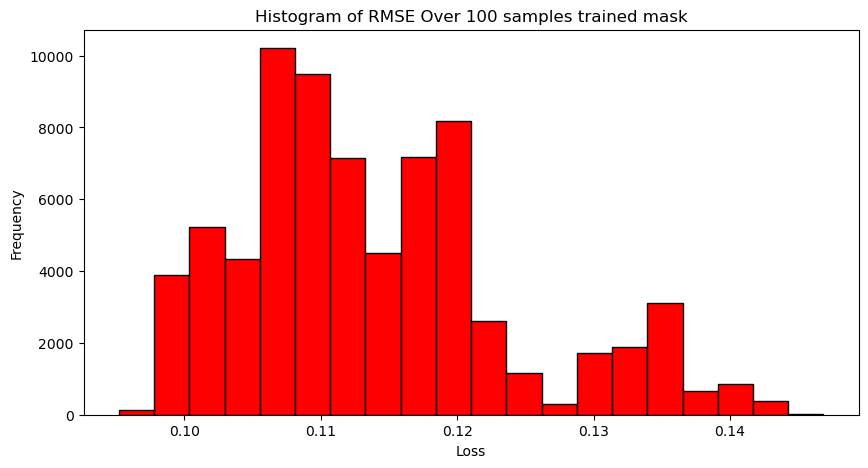

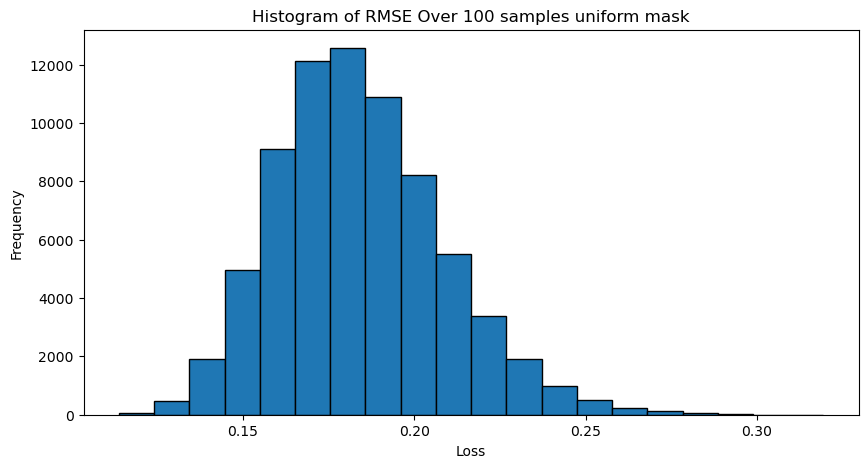

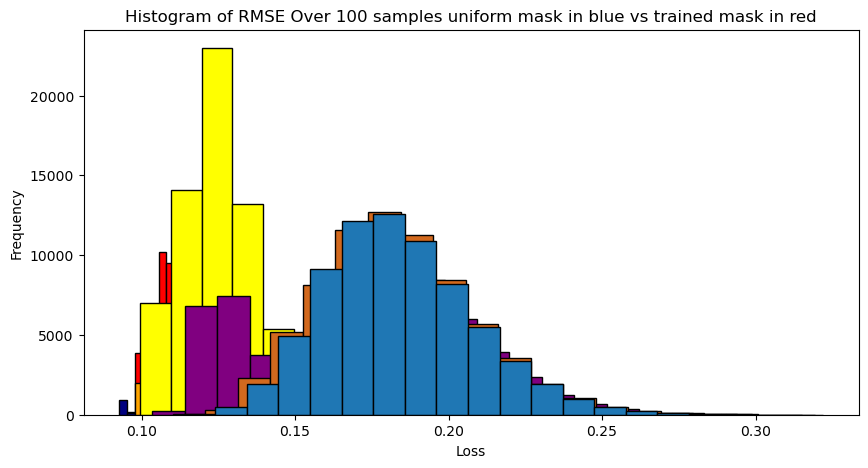

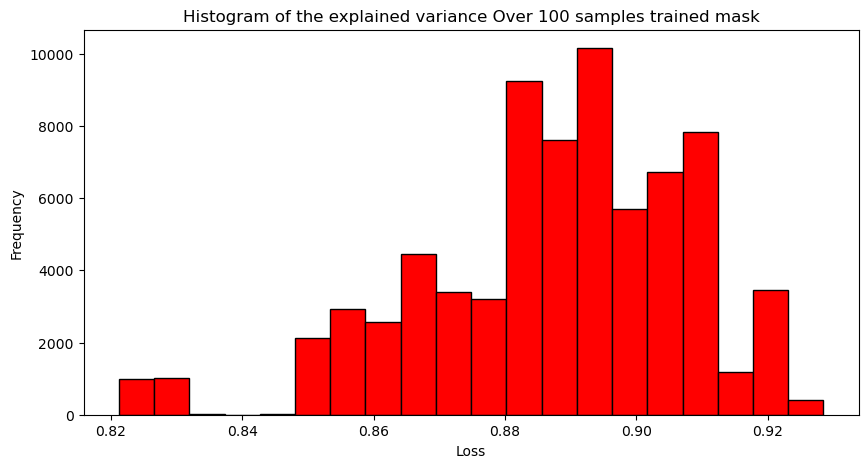

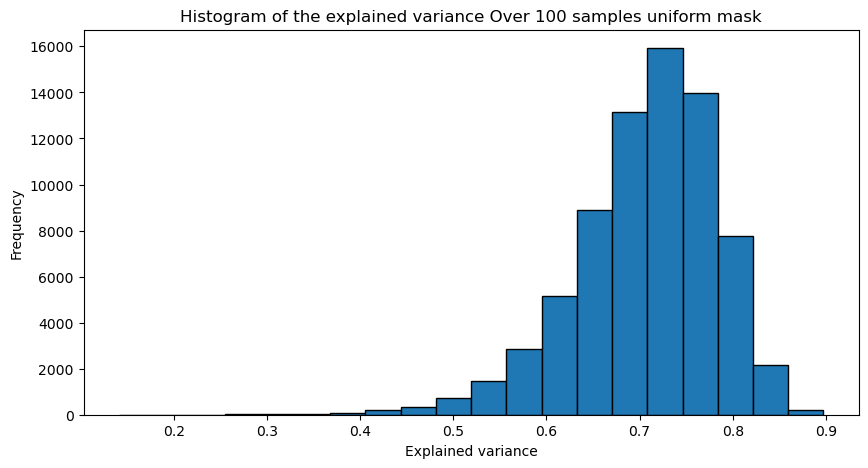

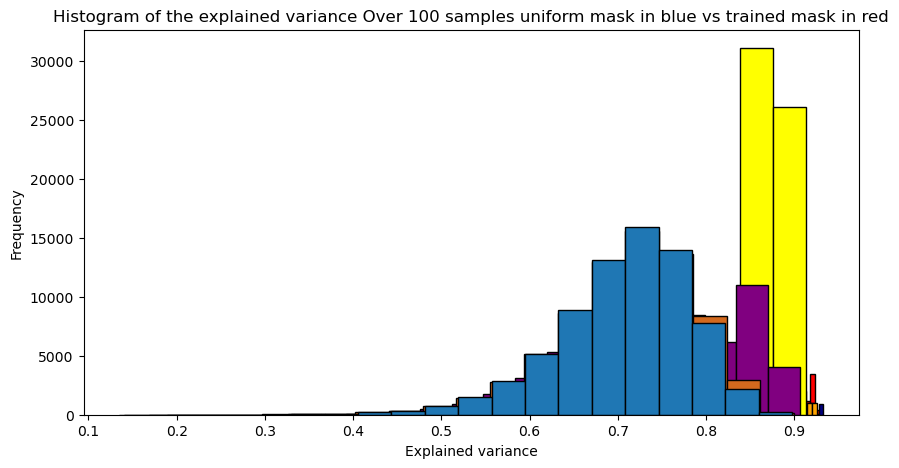

Mean Loss trained: 0.1139422059059143
Mean Loss untrained: 0.18403084576129913
Mean Loss trained: 0.8877187893664183
Mean Loss untrained: 0.7072808819916354
Percentage of uniform RMSE values worse than the trained mean RMSE: 100.00%
Percentage of uniform RMSE values better than the trained mean RMSE: 0.00%
Percentage of uniform explained variance values worse than the trained mean EV: 99.99%
Percentage of uniform explained variance values better than the trained mean EV: 0.01%


In [13]:
# Plot histogram of the losses in red
plt.figure(figsize=(10, 5))
plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples trained mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_trained_2, bins=20, edgecolor='black', color='cyan')
plt.hist(losses_trained_5, bins=20, edgecolor='black', color='navy')
plt.hist(losses_trained_10, bins=20, edgecolor='black', color='green')
plt.hist(losses_trained_15, bins=20, edgecolor='black', color='orange')
plt.hist(losses_trained_20, bins=20, edgecolor='black', color='yellow')
plt.hist(losses_trained_30, bins=20, edgecolor='black', color='purple')
plt.hist(losses_trained_40, bins=20, edgecolor='black', color='chocolate')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask in blue vs trained mask in red')
plt.show()

# Plot histogram of the losses in red
plt.figure(figsize=(10, 5))
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples trained mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_trained_2, bins=20, edgecolor='black', color='cyan')
plt.hist(exp_var_trained_5, bins=20, edgecolor='black', color='navy')
plt.hist(exp_var_trained_10, bins=20, edgecolor='black', color='green')
plt.hist(exp_var_trained_15, bins=20, edgecolor='black', color='orange')
plt.hist(exp_var_trained_20, bins=20, edgecolor='black', color='yellow')
plt.hist(exp_var_trained_30, bins=20, edgecolor='black', color='purple')
plt.hist(exp_var_trained_40, bins=20, edgecolor='black', color='chocolate')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask in blue vs trained mask in red')
plt.show()

# Print the mean of the losses
mean_loss_value_trained = np.mean(losses_trained)
print(f"Mean Loss trained: {mean_loss_value_trained}")

# Print the mean of the losses
mean_loss_value_init = np.mean(losses_init)
print(f"Mean Loss untrained: {mean_loss_value_init}")

# Print the mean of the losses
expvar_loss_value_trained = np.mean(exp_var_trained)
print(f"Mean Loss trained: {expvar_loss_value_trained}")

# Print the mean of the losses
expvar_loss_value_init = np.mean(exp_var_init)
print(f"Mean Loss untrained: {expvar_loss_value_init}")


# Count how many uniform samples have RMSE worse than the trained mean RMSE
worse_rmse_count = np.sum(np.array(losses_init) > mean_loss_value_trained)
better_rmse_count = np.sum(np.array(losses_init) < mean_loss_value_trained)
total_uniform_samples = len(losses_init)

percentage_worse_rmse = (worse_rmse_count / total_uniform_samples) * 100
percentage_better_rmse = (better_rmse_count / total_uniform_samples) * 100

print(f"Percentage of uniform RMSE values worse than the trained mean RMSE: {percentage_worse_rmse:.2f}%")
print(f"Percentage of uniform RMSE values better than the trained mean RMSE: {percentage_better_rmse:.2f}%")

# For explained variance, higher values are better.
mean_ev_trained = np.mean(exp_var_trained)
mean_ev_uniform = np.mean(exp_var_init)

# Count how many uniform samples have explained variance worse (i.e., lower) than the trained mean
worse_ev_count = np.sum(np.array(exp_var_init) < mean_ev_trained)
better_ev_count = np.sum(np.array(exp_var_init) > mean_ev_trained)
total_uniform_samples_ev = len(exp_var_init)

percentage_worse_ev = (worse_ev_count / total_uniform_samples_ev) * 100
percentage_better_ev = (better_ev_count / total_uniform_samples_ev) * 100

print(f"Percentage of uniform explained variance values worse than the trained mean EV: {percentage_worse_ev:.2f}%")
print(f"Percentage of uniform explained variance values better than the trained mean EV: {percentage_better_ev:.2f}%")

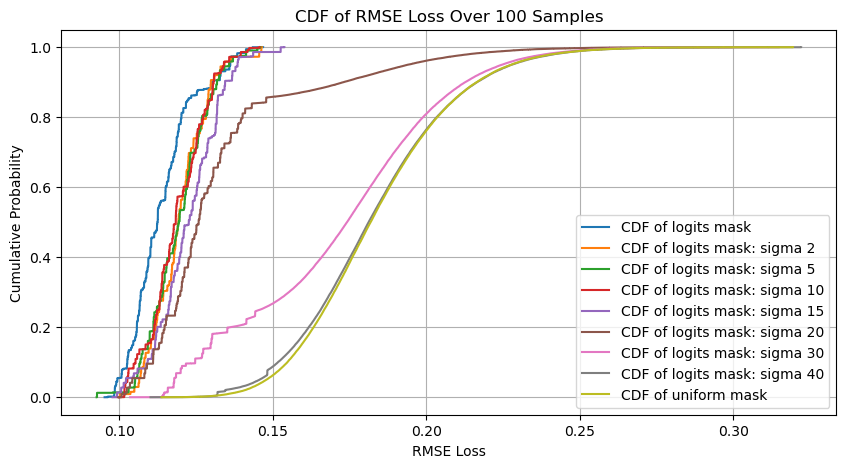

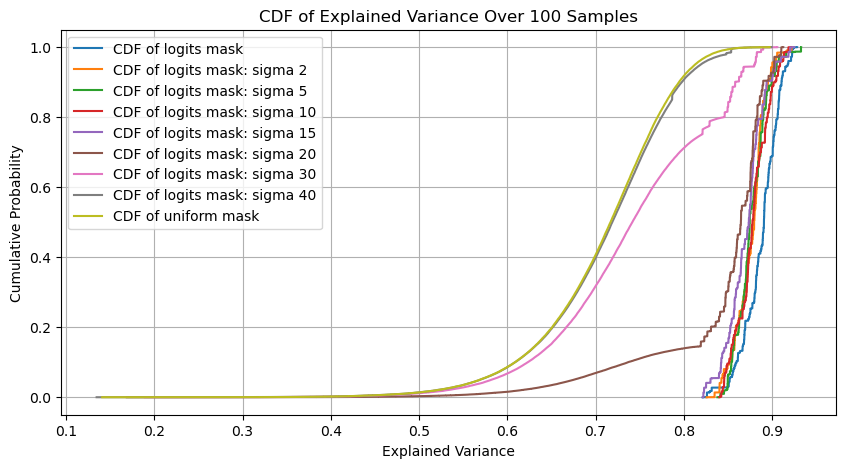

In [14]:
losses_train = np.array(losses_trained)
losses_sorted_train = np.sort(losses_train)
cdf_train = np.arange(1, len(losses_sorted_train) + 1) / len(losses_sorted_train)

losses_train_2 = np.array(losses_trained_2)
losses_sorted_train_2 = np.sort(losses_train_2)
cdf_train_2 = np.arange(1, len(losses_sorted_train_2) + 1) / len(losses_sorted_train_2)

losses_train_5 = np.array(losses_trained_5)
losses_sorted_train_5 = np.sort(losses_train_5)
cdf_train_5 = np.arange(1, len(losses_sorted_train_5) + 1) / len(losses_sorted_train_5)

losses_train_10 = np.array(losses_trained_10)
losses_sorted_train_10 = np.sort(losses_train_10)
cdf_train_10 = np.arange(1, len(losses_sorted_train_10) + 1) / len(losses_sorted_train_10)

losses_train_15 = np.array(losses_trained_15)
losses_sorted_train_15 = np.sort(losses_train_15)
cdf_train_15 = np.arange(1, len(losses_sorted_train_15) + 1) / len(losses_sorted_train_15)

losses_train_20 = np.array(losses_trained_20)
losses_sorted_train_20 = np.sort(losses_train_20)
cdf_train_20 = np.arange(1, len(losses_sorted_train_20) + 1) / len(losses_sorted_train_20)

losses_train_30 = np.array(losses_trained_30)
losses_sorted_train_30 = np.sort(losses_train_30)
cdf_train_30 = np.arange(1, len(losses_sorted_train_30) + 1) / len(losses_sorted_train_30)

losses_train_40 = np.array(losses_trained_40)
losses_sorted_train_40 = np.sort(losses_train_40)
cdf_train_40 = np.arange(1, len(losses_sorted_train_40) + 1) / len(losses_sorted_train_40)

losses = np.array(losses_init)
losses_sorted = np.sort(losses)
cdf = np.arange(1, len(losses_sorted) + 1) / len(losses_sorted)

# Plot the CDF for RMSE loss
plt.figure(figsize=(10, 5))
plt.step(losses_sorted_train, cdf_train, where='post', label='CDF of logits mask')
plt.step(losses_sorted_train_2, cdf_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(losses_sorted_train_5, cdf_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(losses_sorted_train_10, cdf_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(losses_sorted_train_15, cdf_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(losses_sorted_train_20, cdf_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(losses_sorted_train_30, cdf_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(losses_sorted_train_40, cdf_train_40, where='post', label='CDF of logits mask: sigma 40')
plt.step(losses_sorted, cdf, where='post', label='CDF of uniform mask')
plt.xlabel('RMSE Loss')
plt.ylabel('Cumulative Probability')
plt.title('CDF of RMSE Loss Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

exp_var_train = np.array(exp_var_trained)
exp_var_sorted_train = np.sort(exp_var_train)
cdf_exp_train = np.arange(1, len(exp_var_sorted_train) + 1) / len(exp_var_sorted_train)

exp_var_train_2 = np.array(exp_var_trained_2)
exp_var_sorted_train_2 = np.sort(exp_var_train_2)
cdf_exp_train_2 = np.arange(1, len(exp_var_sorted_train_2) + 1) / len(exp_var_sorted_train_2)

exp_var_train_5 = np.array(exp_var_trained_5)
exp_var_sorted_train_5 = np.sort(exp_var_train_5)
cdf_exp_train_5 = np.arange(1, len(exp_var_sorted_train_5) + 1) / len(exp_var_sorted_train_5)

exp_var_train_10 = np.array(exp_var_trained_10)
exp_var_sorted_train_10 = np.sort(exp_var_train_10)
cdf_exp_train_10 = np.arange(1, len(exp_var_sorted_train_10) + 1) / len(exp_var_sorted_train_10)

exp_var_train_15 = np.array(exp_var_trained_15)
exp_var_sorted_train_15 = np.sort(exp_var_train_15)
cdf_exp_train_15 = np.arange(1, len(exp_var_sorted_train_15) + 1) / len(exp_var_sorted_train_15)

exp_var_train_20 = np.array(exp_var_trained_20)
exp_var_sorted_train_20 = np.sort(exp_var_train_20)
cdf_exp_train_20 = np.arange(1, len(exp_var_sorted_train_20) + 1) / len(exp_var_sorted_train_20)

exp_var_train_30 = np.array(exp_var_trained_30)
exp_var_sorted_train_30 = np.sort(exp_var_train_30)
cdf_exp_train_30 = np.arange(1, len(exp_var_sorted_train_30) + 1) / len(exp_var_sorted_train_30)

exp_var_train_40 = np.array(exp_var_trained_40)
exp_var_sorted_train_40 = np.sort(exp_var_train_40)
cdf_exp_train_40 = np.arange(1, len(exp_var_sorted_train_40) + 1) / len(exp_var_sorted_train_40)

exp_var = np.array(exp_var_init)
exp_var_sorted = np.sort(exp_var)
cdf_exp = np.arange(1, len(exp_var_sorted) + 1) / len(exp_var_sorted)

# Plot the CDF for explained variance
plt.figure(figsize=(10, 5))
plt.step(exp_var_sorted_train, cdf_exp_train, where='post', label='CDF of logits mask')
plt.step(exp_var_sorted_train_2, cdf_exp_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(exp_var_sorted_train_5, cdf_exp_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(exp_var_sorted_train_10, cdf_exp_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(exp_var_sorted_train_15, cdf_exp_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(exp_var_sorted_train_20, cdf_exp_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(exp_var_sorted_train_30, cdf_exp_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(exp_var_sorted_train_40, cdf_exp_train_40, where='post', label='CDF of logits mask: sigma 40')
plt.step(exp_var_sorted, cdf_exp, where='post', label='CDF of uniform mask')

plt.xlabel('Explained Variance')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Explained Variance Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()


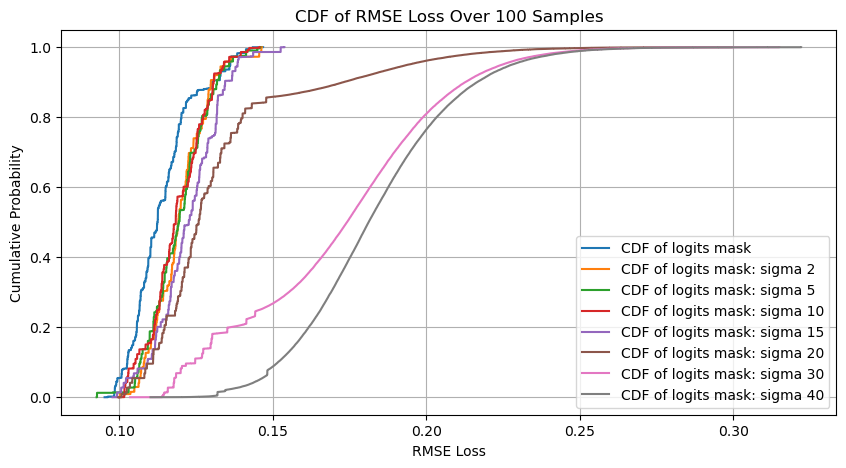

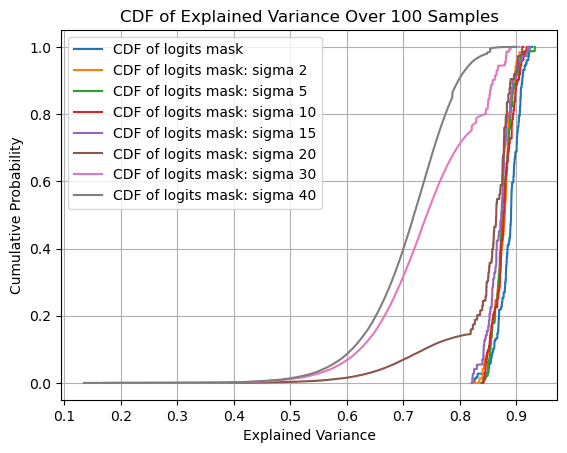

In [15]:
# Plot the CDF for RMSE loss
plt.figure(figsize=(10, 5))
plt.step(losses_sorted_train, cdf_train, where='post', label='CDF of logits mask')
plt.step(losses_sorted_train_2, cdf_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(losses_sorted_train_5, cdf_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(losses_sorted_train_10, cdf_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(losses_sorted_train_15, cdf_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(losses_sorted_train_20, cdf_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(losses_sorted_train_30, cdf_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(losses_sorted_train_40, cdf_train_40, where='post', label='CDF of logits mask: sigma 40')
plt.xlabel('RMSE Loss')
plt.ylabel('Cumulative Probability')
plt.title('CDF of RMSE Loss Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

# Plot the CDF for explained variance
plt.step(exp_var_sorted_train, cdf_exp_train, where='post', label='CDF of logits mask')
plt.step(exp_var_sorted_train_2, cdf_exp_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(exp_var_sorted_train_5, cdf_exp_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(exp_var_sorted_train_10, cdf_exp_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(exp_var_sorted_train_15, cdf_exp_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(exp_var_sorted_train_20, cdf_exp_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(exp_var_sorted_train_30, cdf_exp_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(exp_var_sorted_train_40, cdf_exp_train_40, where='post', label='CDF of logits mask: sigma 40') 

plt.xlabel('Explained Variance')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Explained Variance Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()


In [16]:
def stratified_block_sampling(Nx, Ny, num_selected, seed=0):
    """
    Generates a stratified sampling mask of size Nx x Ny with 1s at selected points and 0s elsewhere.
    Selects exactly `num_selected` points while ensuring non-square block partitioning.
    """
    np.random.seed(seed)

    # Determine the best aspect ratio for blocks
    aspect_ratio = Nx / Ny
    n_blocks_x = max(1, int(np.sqrt(num_selected * aspect_ratio)))
    n_blocks_y = max(1, int(np.sqrt(num_selected / aspect_ratio)))

    # Ensure we have at least num_selected blocks
    total_blocks = n_blocks_x * n_blocks_y
    while total_blocks < num_selected:
        if n_blocks_x < Nx:
            n_blocks_x += 1
        if n_blocks_y < Ny and total_blocks < num_selected:
            n_blocks_y += 1
        total_blocks = n_blocks_x * n_blocks_y

    block_size_x = Nx // n_blocks_x
    block_size_y = Ny // n_blocks_y

    grid = np.zeros((Nx, Ny), dtype=int)
    selected_points = []
    count = 0

    for bx in range(n_blocks_x):
        for by in range(n_blocks_y):
            if count >= num_selected:
                break

            # Define block boundaries
            x_start = bx * block_size_x
            x_end = min((bx + 1) * block_size_x, Nx)
            y_start = by * block_size_y
            y_end = min((by + 1) * block_size_y, Ny)

            # Randomly select a point in this block
            x_rand = np.random.randint(x_start, x_end)
            y_rand = np.random.randint(y_start, y_end)

            if grid[x_rand, y_rand] == 0:  # Ensure uniqueness
                grid[x_rand, y_rand] = 1
                selected_points.append((x_rand, y_rand))
                count += 1

    # If we haven't reached `num_selected`, add more points randomly
    if count < num_selected:
        remaining_indices = np.argwhere(grid == 0)
        np.random.shuffle(remaining_indices)
        for i in range(num_selected - count):
            x, y = remaining_indices[i]
            grid[x, y] = 1
            selected_points.append((x, y))

    return grid, selected_points


def edge_based_sampling(Nx, Ny, num_selected, seed=0):
    """
    Generates a sampling mask of size Nx x Ny with an 8x9 grid.
    - One point per block (randomly placed on edges).
    - First block gets a fully random initialization.
    - Additional points are added if needed.
    """
    np.random.seed(seed)

    # Define grid blocks
    n_blocks_x = 8
    n_blocks_y = 9

    block_size_x = Nx // n_blocks_x
    block_size_y = Ny // n_blocks_y

    grid = np.zeros((Nx, Ny), dtype=int)
    selected_points = []
    count = 0

    # Step 1: Place one point per block (edges)
    for bx in range(n_blocks_x):
        for by in range(n_blocks_y):
            if count >= num_selected:
                break

            # Define block boundaries
            x_start = bx * block_size_x
            x_end = min((bx + 1) * block_size_x, Nx)
            y_start = by * block_size_y
            y_end = min((by + 1) * block_size_y, Ny)

            # First block: Fully random selection
            if bx == 0 and by == 0:
                x_rand = np.random.randint(x_start, x_end)
                y_rand = np.random.randint(y_start, y_end)
            else:
                # Edge selection: Choose from top/bottom row or left/right column
                edge_x = [x_start, x_end - 1]  # Top or bottom row
                edge_y = [y_start, y_end - 1]  # Left or right column
                
                if np.random.rand() > 0.5:  # Randomly select an edge
                    x_rand = np.random.choice(edge_x)
                    y_rand = np.random.randint(y_start, y_end)
                else:
                    x_rand = np.random.randint(x_start, x_end)
                    y_rand = np.random.choice(edge_y)

            if grid[x_rand, y_rand] == 0:  # Ensure uniqueness
                grid[x_rand, y_rand] = 1
                selected_points.append((x_rand, y_rand))
                count += 1

    # Step 2: If more points are needed, add randomly
    if count < num_selected:
        remaining_indices = np.argwhere(grid == 0)
        np.random.shuffle(remaining_indices)
        for i in range(num_selected - count):
            x, y = remaining_indices[i]
            grid[x, y] = 1
            selected_points.append((x, y))
    return grid, selected_points


In [ ]:
losses_strat = []
exp_var_strat = []

losses_edge = []
exp_var_edge = []

for time_index in time_loss:
    TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

    inp_da = tgt_ds.ssh.sel(time=time_index)
    inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

    border_size = 30

    lat_shape = len(inp_da_GS.lat)
    lon_shape = len(inp_da_GS.lon)

    crop_lat_start =  border_size
    crop_lat_end = lat_shape -  border_size
    crop_lon_start =  border_size
    crop_lon_end = lon_shape -  border_size

    inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

    inp_da_GS.fillna(0.0)

    time= 1
    lat, lon =  inp_da_GS_crop.shape

    mean_tgt = inp_da_GS_crop.mean().item()
    std_tgt = inp_da_GS_crop.std().item()

    tens_inp_da = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
    tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da.requires_grad_(True)

    tgt_inp = tens_inp_da.clone()
    grid_size = lat

    batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)
    for _ in range(1000):
        total_points = lat * lon
        num_selected = max(1, int(0.001 * total_points))  # Ensure at least one point is selected

        # Generate stratified mask
        stratified_mask, selected_points = stratified_block_sampling(lat, lon, num_selected, seed=_)

        # Convert to tensor and expand dimensions to match `tgt_inp` shape
        mask_input = torch.tensor(stratified_mask, dtype=torch.float32, device=tgt_inp.device).unsqueeze(0).unsqueeze(0)  # [1, 1, lat, lon]

        # Expand across time dimension if necessary
        mask_input = mask_input.expand(1, time, lat, lon)  # Ensure shape matches `tgt_inp`

        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')

        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[0])

        # Convert to numpy
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        # Compute RMSE loss
        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))
        losses_strat.append(rmse_loss)

        # Compute explained variance
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_strat.append(explained_variance)


    for _ in range(1000):
        total_points = lat * lon
        num_selected = max(1, int(0.001 * total_points))  # Ensure at least one point is selected

        # Generate the edge-based mask
        edge_mask, selected_points = edge_based_sampling(lat, lon, num_selected, seed=_)

        # Convert to tensor and expand dimensions to match `tgt_inp` shape
        mask_input = torch.tensor(edge_mask, dtype=torch.float32, device=tgt_inp.device).unsqueeze(0).unsqueeze(0)  # [1, 1, lat, lon]
        mask_input = mask_input.expand(1, time, lat, lon)  # Ensure shape matches `tgt_inp`

        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')

        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[0])

        # Convert to numpy
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        # Compute RMSE loss
        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))
        losses_edge.append(rmse_loss)

        # Compute explained variance
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_edge.append(explained_variance)

In [ ]:
losses_strats = np.array(losses_strat)
losses_sorted_strat = np.sort(losses_strats)
cdf_strat = np.arange(1, len(losses_sorted_strat) + 1) / len(losses_sorted_strat)

losses_edges = np.array(losses_edge)
losses_sorted_edge = np.sort(losses_edges)
cdf_edge = np.arange(1, len(losses_sorted_edge) + 1) / len(losses_sorted_edge)

exp_var_strats = np.array(exp_var_strat)
exp_var_sorted_strat = np.sort(exp_var_strats)
cdf_exp_strat = np.arange(1, len(exp_var_sorted_strat) + 1) / len(exp_var_sorted_strat)

exp_var_edges = np.array(exp_var_edge)
exp_var_sorted_edge = np.sort(exp_var_edges)
cdf_exp_edge = np.arange(1, len(exp_var_sorted_edge) + 1) / len(exp_var_sorted_edge)

# Plot the CDF for RMSE loss
plt.figure(figsize=(10, 5))
plt.step(losses_sorted_train, cdf_train, where='post', label='CDF of logits mask')
plt.step(losses_sorted_train_2, cdf_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(losses_sorted_train_5, cdf_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(losses_sorted_train_10, cdf_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(losses_sorted_train_15, cdf_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(losses_sorted_train_20, cdf_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(losses_sorted_train_30, cdf_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(losses_sorted_train_40, cdf_train_40, where='post', label='CDF of logits mask: sigma 40')
plt.step(losses_sorted, cdf, where='post', label='CDF of uniform mask')
plt.step(losses_sorted_strat, cdf_strat, where='post', label='CDF of uniform grid mask')
plt.step(losses_sorted_edge, cdf_edge, where='post', label='CDF of edge-based mask')
plt.xlabel('RMSE Loss')
plt.ylabel('Cumulative Probability')
plt.title('CDF of RMSE Loss Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

# Plot the CDF for explained variance
plt.figure(figsize=(10, 5))
plt.step(exp_var_sorted_train, cdf_exp_train, where='post', label='CDF of logits mask')
plt.step(exp_var_sorted_train_2, cdf_exp_train_2, where='post', label='CDF of logits mask: sigma 2')
plt.step(exp_var_sorted_train_5, cdf_exp_train_5, where='post', label='CDF of logits mask: sigma 5')
plt.step(exp_var_sorted_train_10, cdf_exp_train_10, where='post', label='CDF of logits mask: sigma 10')
plt.step(exp_var_sorted_train_15, cdf_exp_train_15, where='post', label='CDF of logits mask: sigma 15')
plt.step(exp_var_sorted_train_20, cdf_exp_train_20, where='post', label='CDF of logits mask: sigma 20')
plt.step(exp_var_sorted_train_30, cdf_exp_train_30, where='post', label='CDF of logits mask: sigma 30')
plt.step(exp_var_sorted_train_40, cdf_exp_train_40, where='post', label='CDF of logits mask: sigma 40')
plt.step(exp_var_sorted, cdf_exp, where='post', label='CDF of uniform mask')
plt.step(exp_var_sorted_strat, cdf_exp_strat, where='post', label='CDF of uniform grid mask')
plt.step(exp_var_sorted_edge, cdf_exp_edge, where='post', label='CDF of edge-based mask')

plt.xlabel('Explained Variance')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Explained Variance Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
losses_trained = []
exp_var_trained = []

losses_trained_1 = []
exp_var_trained_1 = []

losses_trained_2 = []
exp_var_trained_2 = []

losses_trained_3 = []
exp_var_trained_3 = []

losses_trained_7 = []
exp_var_trained_7 = []

losses_init = []
exp_var_init = []

tau = 1
hard = True 
padding_size = 10  # Adjust this value as needed
rate = 0.999

for time_index in range(8, len(tgt_ds.time) - 8):
    TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

    inp_da = tgt_ds.ssh.isel(time=time_index)
    inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

    border_size = 30

    lat_shape = len(inp_da_GS.lat)
    lon_shape = len(inp_da_GS.lon)

    crop_lat_start =  border_size
    crop_lat_end = lat_shape -  border_size
    crop_lon_start =  border_size
    crop_lon_end = lon_shape -  border_size

    inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

    inp_da_GS.fillna(0.0)

    time= 1
    lat, lon =  inp_da_GS_crop.shape

    mean_tgt = inp_da_GS_crop.mean().item()
    std_tgt = inp_da_GS_crop.std().item()

    tens_inp_da = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
    tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da = tens_inp_da.unsqueeze(0)
    tens_inp_da.requires_grad_(True)

    tgt_inp = tens_inp_da.clone()
    grid_size = lat

    batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

    logits_inits_init = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_inits_init[1, :, :, :] = np.log(rate / (1 - rate))
    
    logits = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index).values).float().to(device)

    logits_1 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_1[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index - 1).values).float().to(device)

    logits_2 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_2[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index - 2).values).float().to(device)

    logits_3 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_3[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index - 3).values).float().to(device)

    logits_7 = torch.zeros((2,1,grid_size,grid_size)).to(device)
    logits_7[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index - 7).values).float().to(device)
    
    length_scale = loss_ds.length_scale.isel(time=time_index).values
    length_scale_1 = loss_ds.length_scale.isel(time=time_index - 1).values
    length_scale_2 = loss_ds.length_scale.isel(time=time_index - 2).values
    length_scale_3 = loss_ds.length_scale.isel(time=time_index - 3).values
    length_scale_7 = loss_ds.length_scale.isel(time=time_index - 3).values

    print(length_scale[-1])

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained.append(explained_variance)

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits_1, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_1[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_1.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_1.append(explained_variance)

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits_2, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_2[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_2.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_2.append(explained_variance)

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits_3, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_3[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_3.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_3.append(explained_variance)

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits_7, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0).to(device)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale_7[-1])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_trained_7.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_trained_7.append(explained_variance)

    for _ in range(100):
        gs_output = F.gumbel_softmax(logits_inits_init, hard=True, dim=0)[0, :, :, :]
        mask_input = gs_output.view(time,lat, lon)
        mask_input = mask_input.unsqueeze(0)  # Add batch dimension if necessary
        mask = mask_input
        selected_tgt_inp = tgt_inp * mask
        selected_tgt_inp[mask == 0] = float('nan')
        # Perform optimal interpolation
        output = optimal_interpolation(selected_tgt_inp[0,0], length_scale=length_scale[0])

        # Plot the output tensor
        output_numpy = output.detach().cpu().numpy()
        tgt_center_numpy = batch.tgt.detach().cpu().numpy()

        output_numpy_non = (output_numpy * std_tgt) + mean_tgt
        tgt_center_non = (tgt_center_numpy * std_tgt) + mean_tgt

        rmse_loss = np.sqrt(np.nanmean((tgt_center_non - output_numpy_non) ** 2))

        #loss_mse = F.mse_loss(output_center, tgt_center[0,0])
        losses_init.append(rmse_loss)

        # Calculate variance of residuals and actual values
        residual_variance = np.var(output_numpy_non - tgt_center_non, ddof=1)
        actual_variance = np.var(tgt_center_non, ddof=1)

        # Explained Variance
        explained_variance = 1 - (residual_variance / actual_variance)
        exp_var_init.append(explained_variance)

In [ ]:
# Plot histogram of the losses in red
plt.figure(figsize=(10, 5))
plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples trained mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(losses_init, bins=20, edgecolor='black')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(losses_trained, bins=20, edgecolor='black', color='red', label='logits')
plt.hist(losses_trained_1, bins=20, edgecolor='black', color='green', label='1 days')  
plt.hist(losses_trained_2, bins=20, edgecolor='black', color='yellow', label='2 days')
plt.hist(losses_trained_3, bins=20, edgecolor='black', color='cyan', label='3 days')
plt.hist(losses_trained_7, bins=20, edgecolor='black', color='orange', label='7 days')
plt.hist(losses_init, bins=20, edgecolor='black', label='uniform')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of RMSE Over 100 samples uniform mask in blue vs trained mask in red for each day')
plt.show()

# Plot histogram of the losses in red
plt.figure(figsize=(10, 5))
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red')
plt.xlabel('Loss')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples trained mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
#plt.hist(losses_trained, bins=20, edgecolor='black', color='red')
plt.hist(exp_var_init, bins=20, edgecolor='black')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask')
plt.show()

# Plot histogram of the losses
plt.figure(figsize=(10, 5))
plt.hist(exp_var_trained, bins=20, edgecolor='black', color='red', label='logits')
plt.hist(exp_var_trained_1, bins=20, edgecolor='black', color='green', label='1 days')
plt.hist(exp_var_trained_2, bins=20, edgecolor='black', color='yellow', label='2 days')
plt.hist(exp_var_trained_3, bins=20, edgecolor='black', color='cyan', label='3 days')
plt.hist(exp_var_trained_7, bins=20, edgecolor='black', color='orange', label='7 days')
plt.hist(exp_var_init, bins=20, edgecolor='black', label='uniform')
plt.xlabel('Explained variance')
plt.ylabel('Frequency')
plt.title('Histogram of the explained variance Over 100 samples uniform mask in blue vs trained mask in red for each day')
plt.show()

# Print the mean of the losses
mean_loss_value_trained = np.mean(losses_trained)
print(f"Mean Loss trained: {mean_loss_value_trained}")

# Print the mean of the losses
mean_loss_value_init = np.mean(losses_init)
print(f"Mean Loss untrained: {mean_loss_value_init}")

# Print the mean of the losses
expvar_loss_value_trained = np.mean(exp_var_trained)
print(f"Mean Loss trained: {expvar_loss_value_trained}")

# Print the mean of the losses
expvar_loss_value_init = np.mean(exp_var_init)
print(f"Mean Loss untrained: {expvar_loss_value_init}")


# Count how many uniform samples have RMSE worse than the trained mean RMSE
worse_rmse_count = np.sum(np.array(losses_init) > mean_loss_value_trained)
better_rmse_count = np.sum(np.array(losses_init) < mean_loss_value_trained)
total_uniform_samples = len(losses_init)

percentage_worse_rmse = (worse_rmse_count / total_uniform_samples) * 100
percentage_better_rmse = (better_rmse_count / total_uniform_samples) * 100

print(f"Percentage of uniform RMSE values worse than the trained mean RMSE: {percentage_worse_rmse:.2f}%")
print(f"Percentage of uniform RMSE values better than the trained mean RMSE: {percentage_better_rmse:.2f}%")

# For explained variance, higher values are better.
mean_ev_trained = np.mean(exp_var_trained)
mean_ev_uniform = np.mean(exp_var_init)

# Count how many uniform samples have explained variance worse (i.e., lower) than the trained mean
worse_ev_count = np.sum(np.array(exp_var_init) < mean_ev_trained)
better_ev_count = np.sum(np.array(exp_var_init) > mean_ev_trained)
total_uniform_samples_ev = len(exp_var_init)

percentage_worse_ev = (worse_ev_count / total_uniform_samples_ev) * 100
percentage_better_ev = (better_ev_count / total_uniform_samples_ev) * 100

print(f"Percentage of uniform explained variance values worse than the trained mean EV: {percentage_worse_ev:.2f}%")
print(f"Percentage of uniform explained variance values better than the trained mean EV: {percentage_better_ev:.2f}%")

In [ ]:
losses_train = np.array(losses_trained)
losses_sorted_train = np.sort(losses_train)
cdf_train = np.arange(1, len(losses_sorted_train) + 1) / len(losses_sorted_train)

losses_train_1 = np.array(losses_trained_1)
losses_sorted_train_1 = np.sort(losses_train_1)
cdf_train_1 = np.arange(1, len(losses_sorted_train_1) + 1) / len(losses_sorted_train_1)

losses_train_2 = np.array(losses_trained_2)
losses_sorted_train_2 = np.sort(losses_train_2)
cdf_train_2 = np.arange(1, len(losses_sorted_train_2) + 1) / len(losses_sorted_train_2)

losses_train_3 = np.array(losses_trained_3)
losses_sorted_train_3 = np.sort(losses_train_3)
cdf_train_3 = np.arange(1, len(losses_sorted_train_3) + 1) / len(losses_sorted_train_3)

losses_train_7 = np.array(losses_trained_7)
losses_sorted_train_7 = np.sort(losses_train_7)
cdf_train_7 = np.arange(1, len(losses_sorted_train_7) + 1) / len(losses_sorted_train_7)

losses = np.array(losses_init)
losses_sorted = np.sort(losses)
cdf = np.arange(1, len(losses_sorted) + 1) / len(losses_sorted)

plt.figure(figsize=(10, 5))
plt.step(losses_sorted, cdf, where='post', label='CDF of Uniform')
plt.step(losses_sorted_train, cdf_train, where='post', label='CDF of logits')
plt.step(losses_sorted_train_1, cdf_train_1, where='post', label='CDF of logits - 1')
plt.step(losses_sorted_train_2, cdf_train_2, where='post', label='CDF of logits - 2')
plt.step(losses_sorted_train_3, cdf_train_3, where='post', label='CDF of logits - 3')
plt.step(losses_sorted_train_7, cdf_train_7, where='post', label='CDF of logits - 7')
plt.xlabel('RMSE Loss')
plt.ylabel('Cumulative Probability')
plt.title('CDF of RMSE Loss Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

exp_var_train = np.array(exp_var_trained)
exp_var_sorted_train = np.sort(exp_var_train)
cdf_exp_train = np.arange(1, len(exp_var_sorted_train) + 1) / len(exp_var_sorted_train)

exp_var = np.array(exp_var_init)
exp_var_sorted = np.sort(exp_var)
cdf_exp = np.arange(1, len(exp_var_sorted) + 1) / len(exp_var_sorted)

exp_var_train_1 = np.array(exp_var_trained_1)
exp_var_sorted_train_1 = np.sort(exp_var_train_1)
cdf_exp_train_1 = np.arange(1, len(exp_var_sorted_train_1) + 1) / len(exp_var_sorted_train_1)

exp_var_train_2 = np.array(exp_var_trained_2)
exp_var_sorted_train_2 = np.sort(exp_var_train_2)
cdf_exp_train_2 = np.arange(1, len(exp_var_sorted_train_2) + 1) / len(exp_var_sorted_train_2)

exp_var_train_3 = np.array(exp_var_trained_3)
exp_var_sorted_train_3 = np.sort(exp_var_train_3)
cdf_exp_train_3 = np.arange(1, len(exp_var_sorted_train_3) + 1) / len(exp_var_sorted_train_3)

exp_var_train_7 = np.array(exp_var_trained_7)
exp_var_sorted_train_7 = np.sort(exp_var_train_7)
cdf_exp_train_7 = np.arange(1, len(exp_var_sorted_train_7) + 1) / len(exp_var_sorted_train_7)

plt.figure(figsize=(10, 5))
plt.step(exp_var_sorted, cdf_exp, where='post', label='CDF of Uniform')
plt.step(exp_var_sorted_train, cdf_exp_train, where='post', label='CDF of logits')
plt.step(exp_var_sorted_train_1, cdf_exp_train_1, where='post', label='CDF of logits - 1')
plt.step(exp_var_sorted_train_2, cdf_exp_train_2, where='post', label='CDF of logits - 2')
plt.step(exp_var_sorted_train_3, cdf_exp_train_3, where='post', label='CDF of logits - 3')
plt.step(exp_var_sorted_train_7, cdf_exp_train_7, where='post', label='CDF of logits - 7')
plt.xlabel('Explained Variance')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Explained Variance Over 100 Samples')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
inp_da_GS_crop

In [ ]:
# Perform 100 optimal interpolations using learned logits
losses_logits = []
samples_to_plot = [0, 1, 2, 3, 4, 5]  # Indices of the samples to plot
plotted_samples = 0
time_index = 0  # Using the same time index as before

inp_da = tgt_ds.ssh.isel(time=time_index)
inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

border_size = 30

lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start = border_size
crop_lat_end = lat_shape - border_size
crop_lon_start = border_size
crop_lon_end = lon_shape - border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

inp_da_GS.fillna(0.0)

time = 1
lat, lon = inp_da_GS_crop.shape

mean_tgt = inp_da_GS_crop.mean().item()
std_tgt = inp_da_GS_crop.std().item()

tens_inp_da = torch.from_numpy(inp_da_GS_crop.values).float().to(device)
tens_inp_da = (tens_inp_da - mean_tgt) / std_tgt
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da = tens_inp_da.unsqueeze(0)
tens_inp_da.requires_grad_(True)

tgt_inp = tens_inp_da.clone()
grid_size = lat

batch = TrainingItem(input=tens_inp_da, tgt=tens_inp_da)

# Load the learned logits for this time index
logits = torch.zeros((2, 1, grid_size, grid_size)).to(device)
logits[1, :, :, :] = torch.from_numpy(logits_ds.logits.isel(time=time_index).values).float().to(device)
length_scale = loss_ds.length_scale.isel(time=time_index).values

for i in range(100):
    # Generate mask using learned logits
    gs_output = F.gumbel_softmax(logits, hard=True, dim=0)[0, :, :, :]
    mask_input = gs_output.view(time, lat, lon)
    mask_input = mask_input.unsqueeze(0).to(device)
    mask = mask_input
    
    selected_tgt_inp = tgt_inp * mask
    selected_tgt_inp[mask == 0] = float('nan')
    
    # Perform optimal interpolation
    interpolated_data = optimal_interpolation(selected_tgt_inp[0, 0], length_scale=length_scale[-1])
    
    # Convert back to original scale
    interpolated_data_numpy = interpolated_data.detach().cpu().numpy()
    interpolated_data_denorm = (interpolated_data_numpy * std_tgt) + mean_tgt
    original_data = (tens_inp_da[0, 0].detach().cpu().numpy() * std_tgt) + mean_tgt
    
    # Calculate RMSE
    rmse = np.sqrt(np.nanmean((original_data - interpolated_data_denorm) ** 2))
    losses_logits.append(rmse)
    
    if i in samples_to_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace': 0.3})
        
        vmin = np.nanmin(original_data)
        vmax = np.nanmax(original_data)
        
        # Plot the interpolated data
        im1 = axes[0].imshow(interpolated_data_denorm, cmap="viridis", vmax=vmax, vmin=vmin)
        
        # Show observation locations
        mask_numpy = mask[0, 0].detach().cpu().numpy()
        y_coords, x_coords = np.where(mask_numpy == 1)
        axes[0].scatter(x_coords, y_coords, s=2, c="red", marker="o")
        axes[0].set_title("Interpolated Data (Learned Logits)", fontsize=10)
        cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
        cbar1.ax.tick_params(labelsize=8)
        axes[0].set_xticks([])
        axes[0].set_yticks([])
        
        # Plot the error
        vmax_error = 1
        vmin_error = -1
        error = original_data - interpolated_data_denorm
        im2 = axes[1].imshow(error, cmap="coolwarm", vmax=vmax_error, vmin=vmin_error)
        axes[1].set_title(f"Error, RMSE:{rmse:.8f}", fontsize=10)
        cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        cbar2.ax.tick_params(labelsize=8)
        axes[1].set_xticks([])
        axes[1].set_yticks([])
        
        plt.tight_layout()
        plt.show()
        
        plotted_samples += 1

# Plot histogram comparison between random sampling and learned logits
plt.figure(figsize=(12, 6))
plt.hist(mse_values, bins=20, alpha=0.7, edgecolor="black", color="blue", label="Random Sampling", density=True)
plt.hist(losses_logits, bins=20, alpha=0.7, edgecolor="black", color="red", label="Learned Logits", density=True)
plt.xlabel("RMSE")
plt.ylabel("Density")
plt.title("Histogram Comparison: Random Sampling vs Learned Logits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics
print(f"Random Sampling - Mean RMSE: {np.mean(mse_values):.8f}, Std: {np.std(mse_values):.8f}")
print(f"Learned Logits - Mean RMSE: {np.mean(losses_logits):.8f}, Std: {np.std(losses_logits):.8f}")

# Show ground truth for comparison
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(original_data, cmap="viridis")
ax.set_title("Ground Truth")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

# Print individual sample RMSEs for plotted samples
for i in samples_to_plot:
    if i < len(losses_logits):
        print(f"Learned Logits Sample {i + 1} RMSE: {losses_logits[i]:.8f}")
mse_values = []
samples_to_plot = [0, 1, 2, 3, 4, 5]  # Indices of the samples to plot
plotted_samples = 0
time_index = np.random.randint(0, len(tgt_ds.time))
inp_da = tgt_ds.ssh.isel(time=time_index)
inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

border_size = 30

lat_shape = len(inp_da_GS.lat)
lon_shape = len(inp_da_GS.lon)

crop_lat_start =  border_size
crop_lat_end = lat_shape -  border_size
crop_lon_start =  border_size
crop_lon_end = lon_shape -  border_size

inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

inp_da_GS.fillna(0.0)
for i in range(1000):
    # Generate a random mask for missing data
    mask = np.random.choice([0, 1], size=inp_da_GS_crop.shape, p=[0.999, 0.001])  # 10% observed
    data_with_nans = inp_da_GS_crop.values.copy()
    data_with_nans[mask == 0] = np.nan

    # Perform optimal interpolation
    data_with_nans_tensor = torch.tensor(data_with_nans, dtype=torch.float32).to(device)
    interpolated_data = optimal_interpolation(data_with_nans_tensor, length_scale=length_scale[0])

    # Calculate MSE
    mse = np.nanmean((inp_da_GS_crop.values - interpolated_data.cpu().numpy()) ** 2)
    mse_values.append(mse)

    if i in samples_to_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace': 0.3})
        vmin = np.nanmin(inp_da_GS_crop.values)
        vmax = np.nanmax(inp_da_GS_crop.values)
        # Plot the interpolated data
        im1 = axes[0].imshow(interpolated_data.cpu().numpy(), cmap="viridis", vmax=vmax, vmin=vmin)
        y_coords, x_coords = np.where(mask == 1)
        axes[0].scatter(x_coords, y_coords, s=2, c="red", marker="o")
        axes[0].set_title("Interpolated Data", fontsize=10)
        cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
        cbar1.ax.tick_params(labelsize=8)
        axes[0].set_xticks([])
        axes[0].set_yticks([])
        vmax_error = 1
        vmin_error = -1
        # Plot the error (difference between ground truth and interpolated data)
        error = inp_da_GS_crop.values - interpolated_data.cpu().numpy()
        im2 = axes[1].imshow(error, cmap="coolwarm", vmax=vmax_error, vmin=vmin_error)
        axes[1].set_title(f"Error, MSE:{mse:.8f}", fontsize=10)
        cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
        cbar2.ax.tick_params(labelsize=8)
        axes[1].set_xticks([])
        axes[1].set_yticks([])
        
        plt.tight_layout()
        plt.show()

        plotted_samples += 1

# Plot histogram of MSE values
plt.figure(figsize=(10, 5))
plt.hist(mse_values, bins=20, edgecolor="black", color="blue")
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.title("Histogram of MSE for 100 Optimal Interpolations")
plt.show()

# Print MSE values for the 3 plotted samples

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(inp_da_GS_crop.values, cmap="viridis")
ax.set_title(f"Ground Truth")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()
for i in samples_to_plot:
    # Plot the ground truth
    print(f"Sample {i + 1} MSE: {mse_values[i]:.8f}")

In [ ]:
corr_list = []
for time_index in range(len(tgt_ds.time)):
    inp_da = tgt_ds.ssh.isel(time=time_index)
    inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

    border_size = 30
    inp_da_GS.fillna(0.0)

    lat_shape = len(inp_da_GS.lat)
    lon_shape = len(inp_da_GS.lon)

    crop_lat_start =  border_size
    crop_lat_end = lat_shape -  border_size
    crop_lon_start =  border_size
    crop_lon_end = lon_shape -  border_size

    inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

    logits_field = logits_ds.logits.isel(time=time_index)

    ssh_field_numpy = inp_da_GS_crop.values.flatten()
    logits_field_numpy = logits_field.values.flatten()
    correlation_score = np.corrcoef(ssh_field_numpy, logits_field_numpy)[0,1]
    print(correlation_score)
    corr_list.append(correlation_score)

plt.figure(figsize=(10, 5))
plt.plot(tgt_ds.time, corr_list, linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Correlation Score')
plt.title('Correlation logits vs SSH GT')
plt.grid(True)
plt.show()  
    

In [ ]:
corr_list = []
for time_index in range(len(tgt_ds.time)):
    inp_da = tgt_ds.ssh.isel(time=time_index)
    inp_da_GS = inp_da.sel(lat=slice(28, 45.), 
                       lon=slice(-66, -49.))

    border_size = 30
    inp_da_GS.fillna(0.0)

    lat_shape = len(inp_da_GS.lat)
    lon_shape = len(inp_da_GS.lon)

    crop_lat_start =  border_size
    crop_lat_end = lat_shape -  border_size
    crop_lon_start =  border_size
    crop_lon_end = lon_shape -  border_size

    inp_da_GS_crop = inp_da_GS.isel(lat=slice(crop_lat_start, crop_lat_end),
                                lon=slice(crop_lon_start, crop_lon_end))

    # Find local extrema
    local_max = (inp_da_GS_crop == inp_da_GS_crop.max(dim=('lat', 'lon')))
    local_min = (inp_da_GS_crop == inp_da_GS_crop.min(dim=('lat', 'lon')))
    local_extrema = local_max | local_min

    # Create a mask with neighborhood around local extrema
    neighborhood_size = 5  # Adjust the neighborhood size as needed
    mask = np.zeros_like(inp_da_GS_crop.values)
    for i in range(lat_shape):
        for j in range(lon_shape):
            if local_extrema.values[i, j]:
                lat_start = max(0, i - neighborhood_size)
                lat_end = min(lat_shape, i + neighborhood_size + 1)
                lon_start = max(0, j - neighborhood_size)
                lon_end = min(lon_shape, j + neighborhood_size + 1)
                mask[lat_start:lat_end, lon_start:lon_end] = 1

    inp_da_GS_crop.values = mask

    logits_field = logits_ds.logits.isel(time=time_index)

    ssh_field_numpy = inp_da_GS_crop.values.flatten()
    logits_field_numpy = logits_field.values.flatten()
    correlation_score = np.corrcoef(ssh_field_numpy, logits_field_numpy)[0,1]
    print(correlation_score)
    corr_list.append(correlation_score)

plt.figure(figsize=(10, 5))
plt.plot(tgt_ds.time, corr_list, linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Correlation Score')
plt.title('Correlation logits vs SSH GT')
plt.grid(True)
plt.show()  
    